# Notebook to Analyze Slicing-Aided Effects per Lesion Size Quartile

In [1]:
# Import libraries
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.style.use('ggplot')


In [2]:
# Load test lesion properties

slice_properties = pd.read_csv("/wecare/home/lotte/Thesis/CODE/ETZ/slice_properties.csv", dtype={'scan_nr': int})
testslice_properties = slice_properties[slice_properties['scan_nr'] >= 89]

lesion_properties = pd.read_csv("/wecare/home/lotte/Thesis/CODE/tests_and_exploration/lesion_properties.csv", dtype={'label': int})
lesion_properties["subject_nr"] = [int(subject[3:6]) for subject in lesion_properties['Subject']]
lesion_properties["take"] = [int(subject[-1]) for subject in lesion_properties['Subject']]
lesion_properties["subject_lesion"] = [f'{subject}_l{lesion}' for subject, lesion in zip(lesion_properties['subject_nr'], lesion_properties['label'])] 
lesion_properties["subject_lesion+"] = [f'{subject}_{take}_l{lesion}' for subject, take, lesion in zip(lesion_properties['subject_nr'], lesion_properties["take"], lesion_properties['label'])] 
testlesion_properties = lesion_properties[lesion_properties['subject_nr'] >= 89]

# Retrieve original lesion size quartiles
lesion_sizes = list(lesion_properties['area'])
q1 = np.quantile(lesion_sizes, .25)
q2 = np.quantile(lesion_sizes, .5)
q3 = np.quantile(lesion_sizes, .75)
print("Lesion size quartiles:", q1, q2, q3) 


Lesion size quartiles: 199.5 472.0 1537.5


In [3]:
# Define function to add lesion quartiles to loaded datafiles 
def add_sizegroups(model, inplace=False):
    lesion_sizes = [testlesion_properties[testlesion_properties['subject_lesion']==subject_lesion]['area'].item() for subject_lesion in model['subject_lesion']]
    size_groups = []
    for size in lesion_sizes:
        if size <= q1:
            size_groups.append('q1')
        elif size > q1 and size <= q2:
            size_groups.append('q2')
        elif size > q2 and size <= q3:
            size_groups.append('q3')
        elif size > q3:
            size_groups.append('q4')
    model['size'] = lesion_sizes
    model['size_group'] = size_groups

    if not inplace:
        return model

# Define function to easily compute the detection rate for a model for a given size quartile
def qdr(q, model):
    q_count = list(model['size_group']).count(q)
    sub = model[model['size_group']==q]
    detected = sum(sub['detected_at_least_once'])
    return ( detected/q_count ) * 100

In [4]:
# LOAD ALL PER-LESION DETECTION RESULTS FOR ALL MODELS

# v5 Base trained
base_base_5 = pd.read_csv("/wecare/home/lotte/Thesis/CODE/ETZ/YOLO/YOLOv5/evaluation_runs/base_sampled_s/dr.csv", dtype={'subject': int})
add_sizegroups(base_base_5, inplace=True)
base_SAHI_5 = pd.read_csv("/wecare/home/lotte/Thesis/CODE/ETZ/YOLO/YOLOv5/evaluation_runs/base_sampled_s_SAHI/dr.csv", dtype={'subject': int})
add_sizegroups(base_SAHI_5, inplace=True)
base_ROISAHI_5 = pd.read_csv("/wecare/home/lotte/Thesis/CODE/ETZ/YOLO/YOLOv5/evaluation_runs/base_sampled_s_ROISAHI/dr.csv", dtype={'subject': int})
add_sizegroups(base_ROISAHI_5, inplace=True)
# v5 SF trained
SF_base_5 = add_sizegroups(pd.read_csv("/wecare/home/lotte/Thesis/CODE/ETZ/YOLO/YOLOv5/evaluation_runs/SF_s/dr.csv", dtype={'subject': int}))
SF_SAHI_5 = add_sizegroups(pd.read_csv("/wecare/home/lotte/Thesis/CODE/ETZ/YOLO/YOLOv5/evaluation_runs/SF_s_SAHI/dr.csv", dtype={'subject': int}))
SF_ROISAHI_5 = add_sizegroups(pd.read_csv("/wecare/home/lotte/Thesis/CODE/ETZ/YOLO/YOLOv5/evaluation_runs/SF_s_ROISAHI/dr.csv", dtype={'subject': int}))
# v5 ROISF trained
ROISF_base_5 = add_sizegroups(pd.read_csv("/wecare/home/lotte/Thesis/CODE/ETZ/YOLO/YOLOv5/evaluation_runs/SF_boneboxes_s/dr.csv", dtype={'subject': int}))
ROISF_SAHI_5 = add_sizegroups(pd.read_csv("/wecare/home/lotte/Thesis/CODE/ETZ/YOLO/YOLOv5/evaluation_runs/SF_boneboxes_s_SAHI/dr.csv", dtype={'subject': int}))
ROISF_ROISAHI_5 = add_sizegroups(pd.read_csv("/wecare/home/lotte/Thesis/CODE/ETZ/YOLO/YOLOv5/evaluation_runs/SF_boneboxes_s_ROISAHI/dr.csv", dtype={'subject': int}))

# v26 base trained
base_base_26 = add_sizegroups(pd.read_csv("/wecare/home/lotte/Thesis/CODE/ETZ/YOLO/YOLOv26/evaluation_runs/base_sampled_s/dr.csv", dtype={'subject': int}))
base_SAHI_26 = add_sizegroups(pd.read_csv("/wecare/home/lotte/Thesis/CODE/ETZ/YOLO/YOLOv26/evaluation_runs/base_sampled_s_SAHI/dr.csv", dtype={'subject': int}))
base_ROISAHI_26 = add_sizegroups(pd.read_csv("/wecare/home/lotte/Thesis/CODE/ETZ/YOLO/YOLOv26/evaluation_runs/base_sampled_s_ROISAHI/dr.csv", dtype={'subject': int}))
# v26 SF trained
SF_base_26 = add_sizegroups(pd.read_csv("/wecare/home/lotte/Thesis/CODE/ETZ/YOLO/YOLOv26/evaluation_runs/SF_s/dr.csv", dtype={'subject': int}))
SF_SAHI_26 = add_sizegroups(pd.read_csv("/wecare/home/lotte/Thesis/CODE/ETZ/YOLO/YOLOv26/evaluation_runs/SF_s_SAHI/dr.csv", dtype={'subject': int}))
SF_ROISAHI_26 = add_sizegroups(pd.read_csv("/wecare/home/lotte/Thesis/CODE/ETZ/YOLO/YOLOv26/evaluation_runs/SF_s_ROISAHI/dr.csv", dtype={'subject': int}))
# v26 ROISF trained
ROISF_base_26 = add_sizegroups(pd.read_csv("/wecare/home/lotte/Thesis/CODE/ETZ/YOLO/YOLOv26/evaluation_runs/SF_boneboxes_s/dr.csv", dtype={'subject': int}))
ROISF_SAHI_26 = add_sizegroups(pd.read_csv("/wecare/home/lotte/Thesis/CODE/ETZ/YOLO/YOLOv26/evaluation_runs/SF_boneboxes_s_SAHI/dr.csv", dtype={'subject': int}))
ROISF_ROISAHI_26 = add_sizegroups(pd.read_csv("/wecare/home/lotte/Thesis/CODE/ETZ/YOLO/YOLOv26/evaluation_runs/SF_boneboxes_s_ROISAHI/dr.csv", dtype={'subject': int}))

# r base trained
base_base_r = add_sizegroups(pd.read_csv("/wecare/home/lotte/Thesis/CODE/ETZ/RetinaNet/evaluation_runs/base/dr.csv", dtype={'subject': int}))
base_SAHI_r = add_sizegroups(pd.read_csv("/wecare/home/lotte/Thesis/CODE/ETZ/RetinaNet/evaluation_runs/base_SAHI/dr.csv", dtype={'subject': int}))
base_ROISAHI_r = add_sizegroups(pd.read_csv("/wecare/home/lotte/Thesis/CODE/ETZ/RetinaNet/evaluation_runs/base_ROISAHI/dr.csv", dtype={'subject': int}))
# r SF trained
SF_base_r = add_sizegroups(pd.read_csv("/wecare/home/lotte/Thesis/CODE/ETZ/RetinaNet/evaluation_runs/SF/dr.csv", dtype={'subject': int}))
SF_SAHI_r = add_sizegroups(pd.read_csv("/wecare/home/lotte/Thesis/CODE/ETZ/RetinaNet/evaluation_runs/SF_SAHI/dr.csv", dtype={'subject': int}))
SF_ROISAHI_r = add_sizegroups(pd.read_csv("/wecare/home/lotte/Thesis/CODE/ETZ/RetinaNet/evaluation_runs/SF_ROISAHI/dr.csv", dtype={'subject': int}))
# r ROISF trained
ROISF_base_r = add_sizegroups(pd.read_csv("/wecare/home/lotte/Thesis/CODE/ETZ/RetinaNet/evaluation_runs/boneboxes/dr.csv", dtype={'subject': int}))
ROISF_SAHI_r = add_sizegroups(pd.read_csv("/wecare/home/lotte/Thesis/CODE/ETZ/RetinaNet/evaluation_runs/boneboxes_SAHI/dr.csv", dtype={'subject': int}))
ROISF_ROISAHI_r = add_sizegroups(pd.read_csv("/wecare/home/lotte/Thesis/CODE/ETZ/RetinaNet/evaluation_runs/boneboxes_ROISAHI/dr.csv", dtype={'subject': int}))


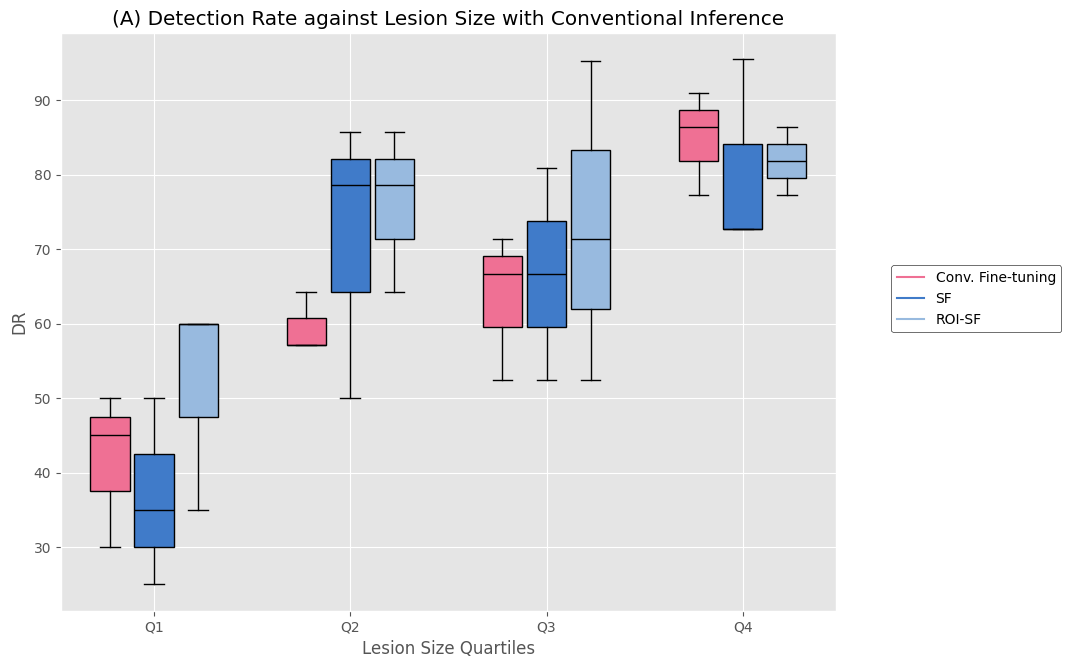

In [7]:
# Create boxplot for tuning methods with base evaluation;

# Gather data
base_q1 = [qdr('q1', base_base_5), qdr('q1', base_base_26), qdr('q1', base_base_r)] 
SF_q1 = [qdr('q1', SF_base_5), qdr('q1', SF_base_26), qdr('q1', SF_base_r)] 
ROISF_q1 = [qdr('q1', ROISF_base_5), qdr('q1', ROISF_base_26), qdr('q1', ROISF_base_r)]

base_q2 = [qdr('q2', base_base_5), qdr('q2', base_base_26), qdr('q2', base_base_r)] 
SF_q2 = [qdr('q2', SF_base_5), qdr('q2', SF_base_26), qdr('q2', SF_base_r)] 
ROISF_q2 = [qdr('q2', ROISF_base_5), qdr('q2', ROISF_base_26), qdr('q2', ROISF_base_r)]

base_q3 = [qdr('q3', base_base_5), qdr('q3', base_base_26), qdr('q3', base_base_r)] 
SF_q3 = [qdr('q3', SF_base_5), qdr('q3', SF_base_26), qdr('q3', SF_base_r)] 
ROISF_q3 = [qdr('q3', ROISF_base_5), qdr('q3', ROISF_base_26), qdr('q3', ROISF_base_r)]

base_q4 = [qdr('q4', base_base_5), qdr('q4', base_base_26), qdr('q4', base_base_r)] 
SF_q4 = [qdr('q4', SF_base_5), qdr('q4', SF_base_26), qdr('q4', SF_base_r)] 
ROISF_q4 = [qdr('q4', ROISF_base_5), qdr('q4', ROISF_base_26), qdr('q4', ROISF_base_r)]

base = [base_q1, base_q2, base_q3, base_q4]
SF = [SF_q1, SF_q2, SF_q3, SF_q4]
ROISF = [ROISF_q1, ROISF_q2, ROISF_q3, ROISF_q4]

# Create figure
plt.figure(figsize=(10,7.5))

medianprops = dict(linestyle='-', linewidth=1, color='black')
base_plot = plt.boxplot(base, patch_artist=True, medianprops=medianprops,
                        positions=np.array(np.arange(len(base)))*2.0-0.45,
                        widths=0.4)
SF_plot = plt.boxplot(SF, patch_artist=True, medianprops=medianprops,
                        positions=np.array(np.arange(len(SF)))*2.0,
                        widths=0.4)
ROISF_plot = plt.boxplot(ROISF, patch_artist=True, medianprops=medianprops,
                        positions=np.array(np.arange(len(ROISF)))*2.0+0.45,
                        widths=0.4)

def box_properties(plot_name, color, label):
    for patch in plot_name['boxes']:
        patch.set_facecolor(color)
    plt.plot([], c=color, label=label)
    plt.legend(bbox_to_anchor=(0.8, 0.11, 0.5, 0.5), facecolor="white", edgecolor='black')

box_properties(base_plot, "#ef7094", 'Conv. Fine-tuning')
box_properties(SF_plot, "#407BC9", 'SF')
box_properties(ROISF_plot, "#98badf", 'ROI-SF')

ticks = ['Q1', 'Q2', 'Q3', 'Q4']
plt.xticks(np.arange(0, len(ticks)*2, 2), ticks)
plt.title('(A) Detection Rate against Lesion Size with Conventional Inference')
plt.xlabel("Lesion Size Quartiles")
plt.ylabel("DR")
plt.savefig("conf_inference.png", bbox_inches='tight')
plt.show()


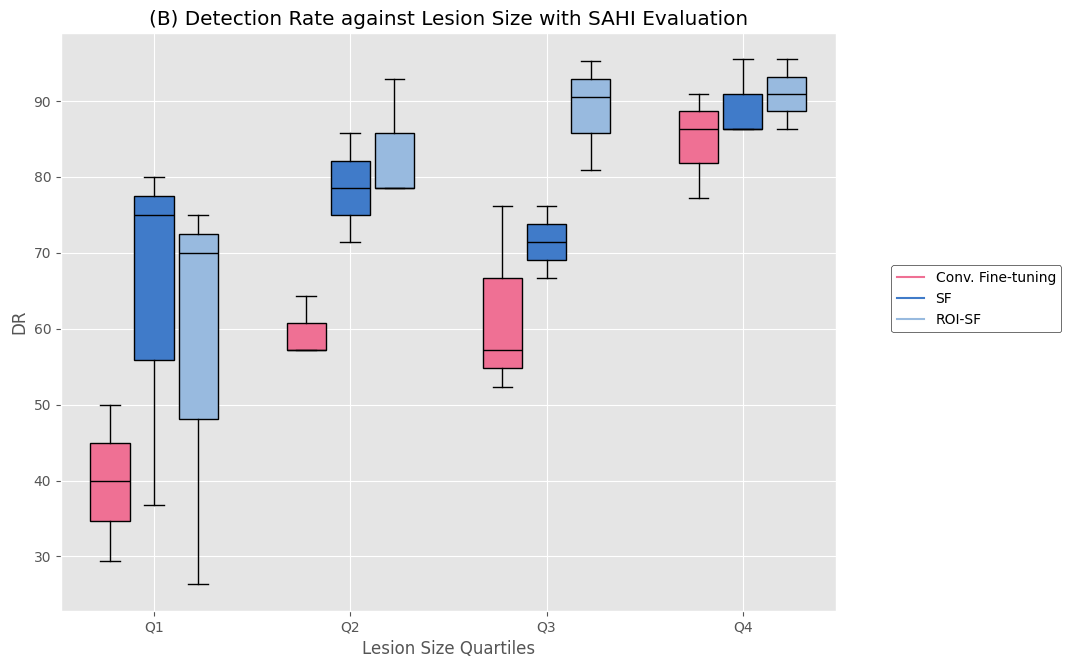

In [8]:
# Create boxplot for tuning methods with SAHI evaluation;

# Gather data
base_q1 = [qdr('q1', base_SAHI_5), qdr('q1', base_SAHI_26), qdr('q1', base_SAHI_r)] 
SF_q1 = [qdr('q1', SF_SAHI_5), qdr('q1', SF_SAHI_26), qdr('q1', SF_SAHI_r)] 
ROISF_q1 = [qdr('q1', ROISF_SAHI_5), qdr('q1', ROISF_SAHI_26), qdr('q1', ROISF_SAHI_r)]

base_q2 = [qdr('q2', base_SAHI_5), qdr('q2', base_SAHI_26), qdr('q2', base_SAHI_r)] 
SF_q2 = [qdr('q2', SF_SAHI_5), qdr('q2', SF_SAHI_26), qdr('q2', SF_SAHI_r)] 
ROISF_q2 = [qdr('q2', ROISF_SAHI_5), qdr('q2', ROISF_SAHI_26), qdr('q2', ROISF_SAHI_r)]

base_q3 = [qdr('q3', base_SAHI_5), qdr('q3', base_SAHI_26), qdr('q3', base_SAHI_r)] 
SF_q3 = [qdr('q3', SF_SAHI_5), qdr('q3', SF_SAHI_26), qdr('q3', SF_SAHI_r)] 
ROISF_q3 = [qdr('q3', ROISF_SAHI_5), qdr('q3', ROISF_SAHI_26), qdr('q3', ROISF_SAHI_r)]

base_q4 = [qdr('q4', base_SAHI_5), qdr('q4', base_SAHI_26), qdr('q4', base_SAHI_r)] 
SF_q4 = [qdr('q4', SF_SAHI_5), qdr('q4', SF_SAHI_26), qdr('q4', SF_SAHI_r)] 
ROISF_q4 = [qdr('q4', ROISF_SAHI_5), qdr('q4', ROISF_SAHI_26), qdr('q4', ROISF_SAHI_r)]

base = [base_q1, base_q2, base_q3, base_q4]
SF = [SF_q1, SF_q2, SF_q3, SF_q4]
ROISF = [ROISF_q1, ROISF_q2, ROISF_q3, ROISF_q4]

# Create figure
plt.figure(figsize=(10,7.5))

medianprops = dict(linestyle='-', linewidth=1, color='black')
base_plot = plt.boxplot(base, patch_artist=True, medianprops=medianprops,
                        positions=np.array(np.arange(len(base)))*2.0-0.45,
                        widths=0.4)
SF_plot = plt.boxplot(SF, patch_artist=True, medianprops=medianprops,
                        positions=np.array(np.arange(len(SF)))*2.0,
                        widths=0.4)
ROISF_plot = plt.boxplot(ROISF, patch_artist=True, medianprops=medianprops,
                        positions=np.array(np.arange(len(ROISF)))*2.0+0.45,
                        widths=0.4)

def box_properties(plot_name, color, label):
    for patch in plot_name['boxes']:
        patch.set_facecolor(color)
    plt.plot([], c=color, label=label)
    plt.legend(bbox_to_anchor=(0.8, 0.11, 0.5, 0.5), facecolor="white", edgecolor='black')

box_properties(base_plot, "#ef7094", 'Conv. Fine-tuning')
box_properties(SF_plot, "#407BC9", 'SF')
box_properties(ROISF_plot, "#98badf", 'ROI-SF')

ticks = ['Q1', 'Q2', 'Q3', 'Q4']
plt.xticks(np.arange(0, len(ticks)*2, 2), ticks)
plt.title('(B) Detection Rate against Lesion Size with SAHI Evaluation')
plt.xlabel("Lesion Size Quartiles")
plt.ylabel("DR")
plt.savefig("sf.png", bbox_inches='tight')
plt.show()




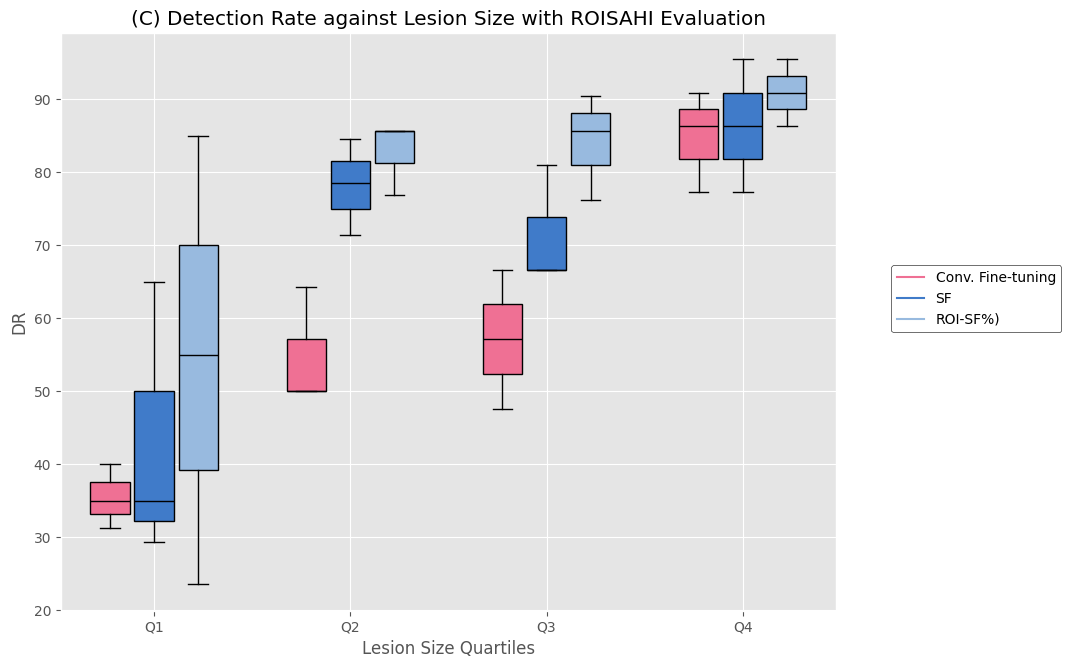

In [9]:
# Create boxplot for tuning methods with ROI-SAHI evaluation;

# Gather data
base_q1 = [qdr('q1', base_ROISAHI_5), qdr('q1', base_ROISAHI_26), qdr('q1', base_ROISAHI_r)] 
SF_q1 = [qdr('q1', SF_ROISAHI_5), qdr('q1', SF_ROISAHI_26), qdr('q1', SF_ROISAHI_r)] 
ROISF_q1 = [qdr('q1', ROISF_ROISAHI_5), qdr('q1', ROISF_ROISAHI_26), qdr('q1', ROISF_ROISAHI_r)]

base_q2 = [qdr('q2', base_ROISAHI_5), qdr('q2', base_ROISAHI_26), qdr('q2', base_ROISAHI_r)] 
SF_q2 = [qdr('q2', SF_ROISAHI_5), qdr('q2', SF_ROISAHI_26), qdr('q2', SF_ROISAHI_r)] 
ROISF_q2 = [qdr('q2', ROISF_ROISAHI_5), qdr('q2', ROISF_ROISAHI_26), qdr('q2', ROISF_ROISAHI_r)]

base_q3 = [qdr('q3', base_ROISAHI_5), qdr('q3', base_ROISAHI_26), qdr('q3', base_ROISAHI_r)] 
SF_q3 = [qdr('q3', SF_ROISAHI_5), qdr('q3', SF_ROISAHI_26), qdr('q3', SF_ROISAHI_r)] 
ROISF_q3 = [qdr('q3', ROISF_ROISAHI_5), qdr('q3', ROISF_ROISAHI_26), qdr('q3', ROISF_ROISAHI_r)]

base_q4 = [qdr('q4', base_ROISAHI_5), qdr('q4', base_ROISAHI_26), qdr('q4', base_ROISAHI_r)] 
SF_q4 = [qdr('q4', SF_ROISAHI_5), qdr('q4', SF_ROISAHI_26), qdr('q4', SF_ROISAHI_r)] 
ROISF_q4 = [qdr('q4', ROISF_ROISAHI_5), qdr('q4', ROISF_ROISAHI_26), qdr('q4', ROISF_ROISAHI_r)]

base = [base_q1, base_q2, base_q3, base_q4]
SF = [SF_q1, SF_q2, SF_q3, SF_q4]
ROISF = [ROISF_q1, ROISF_q2, ROISF_q3, ROISF_q4]

# Create figure
plt.figure(figsize=(10,7.5))

ticks = ['Q1', 'Q2', 'Q3', 'Q4']

medianprops = dict(linestyle='-', linewidth=1, color='black')
base_plot = plt.boxplot(base, patch_artist=True, medianprops=medianprops,
                        positions=np.array(np.arange(len(base)))*2.0-0.45,
                        widths=0.4)
SF_plot = plt.boxplot(SF, patch_artist=True, medianprops=medianprops,
                        positions=np.array(np.arange(len(SF)))*2.0,
                        widths=0.4)
ROISF_plot = plt.boxplot(ROISF, patch_artist=True, medianprops=medianprops,
                        positions=np.array(np.arange(len(ROISF)))*2.0+0.45,
                        widths=0.4)

def box_properties(plot_name, color, label):
    for patch in plot_name['boxes']:
        patch.set_facecolor(color)
    plt.plot([], c=color, label=label)
    plt.legend(bbox_to_anchor=(0.8, 0.11, 0.5, 0.5), facecolor="white", edgecolor='black')

box_properties(base_plot, "#ef7094", 'Conv. Fine-tuning')
box_properties(SF_plot, "#407BC9", 'SF')
box_properties(ROISF_plot, "#98badf", 'ROI-SF%)')

plt.xticks(np.arange(0, len(ticks)*2, 2), ticks)
plt.title('(C) Detection Rate against Lesion Size with ROISAHI Evaluation')
plt.xlabel("Lesion Size Quartiles")
plt.ylabel("DR")
plt.savefig("ROISF.png", bbox_inches='tight')
plt.show()


